# 03 — TorchAO CPU INT8 PTQ

Notes:
- `backend='torchao_cpu_ptq'`, `device='cpu'`, `model_precision='int8'`.
- calib on `val` set


In [13]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path('../src').resolve()))

In [14]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import plot_tradeoff_scatter

pd.set_option("display.max_columns", 200)

In [15]:

base = ExperimentConfig(
    backend="torchao_cpu_ptq",
    device="cpu",
    batch_size=1,             # smaller batch for CPU
    model_precision="int8",     # model precision
    input_quant_bits=1,         
    seed=42,
    num_eval_batches = 1000,
    cpu_calib_split="val",
    cpu_calib_num_batches=1,
)

cfgs = [base]

# # calib sensitivity
# cfgs = [
#     with_overrides(base, cpu_calib_num_batches=5),
#     with_overrides(base, cpu_calib_num_batches=10),
#     with_overrides(base, cpu_calib_num_batches=25),
# ]

In [16]:
records = []
for cfg in cfgs:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/torchao/quantization/pt2e/quantizer/x86_inductor_quantizer.py:1325: UserWarning: The input of maxpool2d is not quantized, skip annotate maxpool2d with config QuantizationConfig(input_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), output_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), weight=QuantizationSpec(dtype=torch.int8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.PerChannelMinMaxObserver'>, eps=0.000244140625){}, quant

Evaluating on 1000 batches...
  Batch [10/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 12.22 ms/batch
  Batch [20/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 10.51 ms/batch
  Batch [30/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 10.45 ms/batch
  Batch [40/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 10.38 ms/batch
  Batch [50/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 10.31 ms/batch
  Batch [60/1000] Top-1: 0.00% | Top-5: 0.00% | Infer: 10.92 ms/batch
  Batch [70/1000] Top-1: 0.00% | Top-5: 1.43% | Infer: 10.79 ms/batch
  Batch [80/1000] Top-1: 0.00% | Top-5: 1.25% | Infer: 10.81 ms/batch
  Batch [90/1000] Top-1: 0.00% | Top-5: 1.11% | Infer: 11.45 ms/batch
  Batch [100/1000] Top-1: 0.00% | Top-5: 1.00% | Infer: 11.61 ms/batch
  Batch [110/1000] Top-1: 0.00% | Top-5: 0.91% | Infer: 11.60 ms/batch
  Batch [120/1000] Top-1: 0.00% | Top-5: 1.67% | Infer: 11.37 ms/batch
  Batch [130/1000] Top-1: 0.00% | Top-5: 1.54% | Infer: 11.38 ms/batch
  Batch [140/1000] Top-1: 0.00% | Top-5: 1.43% | Infer: 

In [17]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

df_int8_cpu = df[
    (df["cfg.backend"] == "torchao_cpu_ptq")
    & (df["cfg.device"] == "cpu")
].copy()

df_int8_cpu[[
    "run_id",
    "cfg.backend",
    "cfg.device",
    "cfg.batch_size",
    "cfg.model_precision",
    "cfg.input_quant_bits",
    "cfg.cpu_calib_num_batches",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["cfg.cpu_calib_num_batches", "cfg.batch_size"])

,run_id,cfg.backend,cfg.device,cfg.batch_size,cfg.model_precision,cfg.input_quant_bits,cfg.cpu_calib_num_batches,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
23,resnet18_torchao_cpu_ptq_int8_in1b_cpu_bs1,torchao_cpu_ptq,cpu,1,int8,1,1,0.8,4.6,10.833057,92.310043,1000
24,resnet18_torchao_cpu_ptq_int8_in2b_cpu_bs1,torchao_cpu_ptq,cpu,1,int8,2,1,35.2,55.7,10.778390,92.778234,1000
25,resnet18_torchao_cpu_ptq_int8_in4b_cpu_bs1,torchao_cpu_ptq,cpu,1,int8,4,1,83.6,95.0,13.090151,76.393310,1000
26,resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs1,torchao_cpu_ptq,cpu,1,int8,8,1,84.8,95.9,10.433682,95.843444,1000


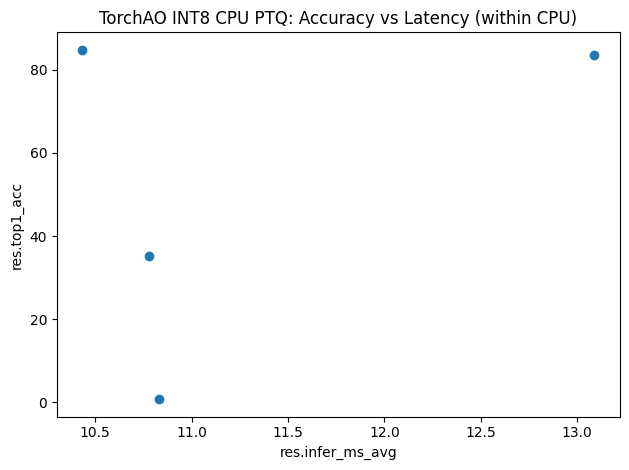

In [18]:
rows_int8_cpu = df_int8_cpu.to_dict(orient="records")
plot_tradeoff_scatter(
    rows_int8_cpu,
    x_key="res.infer_ms_avg",
    y_key="res.top1_acc",
    title="TorchAO INT8 CPU PTQ: Accuracy vs Latency (within CPU)",
    annotate=False,
)

